# Day 3 — Full EDA
**Real Estate Fraud Detection**

Goal: Understand data distributions, fraud patterns, geographic analysis, and statistical significance.

**Prerequisites:**
- Day 1 `01_data_audit.ipynb` completed → `data/processed/ingested.parquet` (2,147,656 rows)
- Day 2 `02_fraud_labeling.ipynb` completed → `data/processed/labeled.parquet` (2,147,656 rows, 19 cols)

## 0. Set Project Root

In [1]:
# FIX: os.chdir setup missing tha Day 3 mein — Day 1 & 2 ki tarah add kiya
import os
from pathlib import Path

project_root = Path.cwd()
while not (project_root / 'configs').exists():
    project_root = project_root.parent
os.chdir(project_root)
print(f"Working directory: {os.getcwd()}")
# Expected: .../real_estate_fraud_detection

Working directory: C:\Users\mehal\Downloads\machinelearning\real_estate_fraud_detection


## 1. Imports & Config

In [2]:
# FIX: abspath('..') → abspath('.')  aur  '../configs/...' → 'configs/...'
import os, sys
sys.path.insert(0, os.path.abspath('.'))

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.ingestion import load_config
from src.eda_utils import (
    univariate_numerical, univariate_categorical,
    bivariate_correlation, fraud_vs_normal,
    mann_whitney_test, fraud_by_geography,
    price_per_sqft_analysis, scatter_fraud_highlight,
    fraud_score_analysis, generate_eda_summary
)

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

# FIX: '../configs/config.yaml' → 'configs/config.yaml'
CONFIG_PATH = 'configs/config.yaml'
# FIX: '../reports/plots' → 'reports/plots'
PLOTS_DIR   = 'reports/plots'
cfg = load_config(CONFIG_PATH)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

print(f'Config loaded: {cfg["project"]["name"]} v{cfg["project"]["version"]}')
print(f'Fraud rules threshold: {cfg["fraud_rules"]["min_fraud_score_threshold"]} rules')

2026-05-11 16:57:18,064 - src.ingestion - INFO - Config loaded from configs\config.yaml — project: real_estate_fraud_detection v1.1.0


Config loaded: real_estate_fraud_detection v1.1.0
Fraud rules threshold: 2 rules


## 2. Load Labeled Data

> **Compatibility Check:** Day 2 (fixed) ne 2,147,656 rows save kiye hain. Agar rows alag hain toh Day 2 notebook phir se run karo.

In [3]:
# FIX: f"../{cfg[...]}labeled.parquet" → Path(cfg[...]) / 'labeled.parquet'
labeled_path = Path(cfg['data']['processed_path']) / 'labeled.parquet'
df = pd.read_parquet(labeled_path)

# ── Compatibility check — Day 1 & 2 se match karna chahiye ─────────────
EXPECTED_ROWS = 2_147_656
EXPECTED_COLS = 19
if len(df) != EXPECTED_ROWS:
    print(f'⚠️  WARNING: Expected {EXPECTED_ROWS:,} rows but got {len(df):,}')
    print('   → Re-run 02_fraud_labeling.ipynb first to regenerate labeled.parquet')
else:
    print(f'✅ Row count matches Day 2 output: {len(df):,}')

if len(df.columns) != EXPECTED_COLS:
    print(f'⚠️  WARNING: Expected {EXPECTED_COLS} columns but got {len(df.columns)}')
    print(f'   Columns present: {list(df.columns)}')
else:
    print(f'✅ Column count correct: {len(df.columns)} columns')

target = cfg['columns']['target']
fraud  = df[df[target] == 1]
normal = df[df[target] == 0]

print(f'\nShape         : {df.shape}')
print(f'Fraud count   : {len(fraud):,}  ({len(fraud)/len(df)*100:.2f}%)')
print(f'Normal count  : {len(normal):,}  ({len(normal)/len(df)*100:.2f}%)')
print(f'Columns       : {list(df.columns)}')

✅ Row count matches Day 2 output: 2,147,656
✅ Column count correct: 19 columns

Shape         : (2147656, 19)
Fraud count   : 168,005  (7.82%)
Normal count  : 1,979,651  (92.18%)
Columns       : ['status', 'price', 'bed', 'bath', 'acre_lot', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date', 'rule_price_low', 'rule_price_high', 'rule_price_per_sqft', 'rule_impossible_dims', 'rule_size_disconnect', 'rule_duplicate', 'rule_state_anomaly', 'fraud_score', 'is_fraud']


## 3. Missing Value Quick Check

In [4]:
missing = (df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False)
missing_df = missing[missing > 0]
if len(missing_df) > 0:
    print('Columns with missing values:')
    print(missing_df.to_string())
else:
    print('✅ No missing values in labeled dataset')
    
print(f'\nDtypes:\n{df.dtypes}')

Columns with missing values:
prev_sold_date   31.71
house_size       23.82
bath             21.30
bed              19.91
acre_lot         14.44
price             0.07
city              0.06
zip_code          0.01

Dtypes:
status                   object
price                   float64
bed                     float64
bath                    float64
acre_lot                float64
city                     object
state                    object
zip_code                float64
house_size              float64
prev_sold_date           object
rule_price_low            int32
rule_price_high           int32
rule_price_per_sqft       int32
rule_impossible_dims      int32
rule_size_disconnect      int32
rule_duplicate            int64
rule_state_anomaly        int32
fraud_score               int64
is_fraud                  int32
dtype: object


## 4. Univariate Analysis — Numerical

Plotting numerical distributions (raw vs log vs boxplot)...


2026-05-11 16:57:36,324 - src.eda_utils - INFO - Plot saved -> reports/plots/univariate_numerical.png


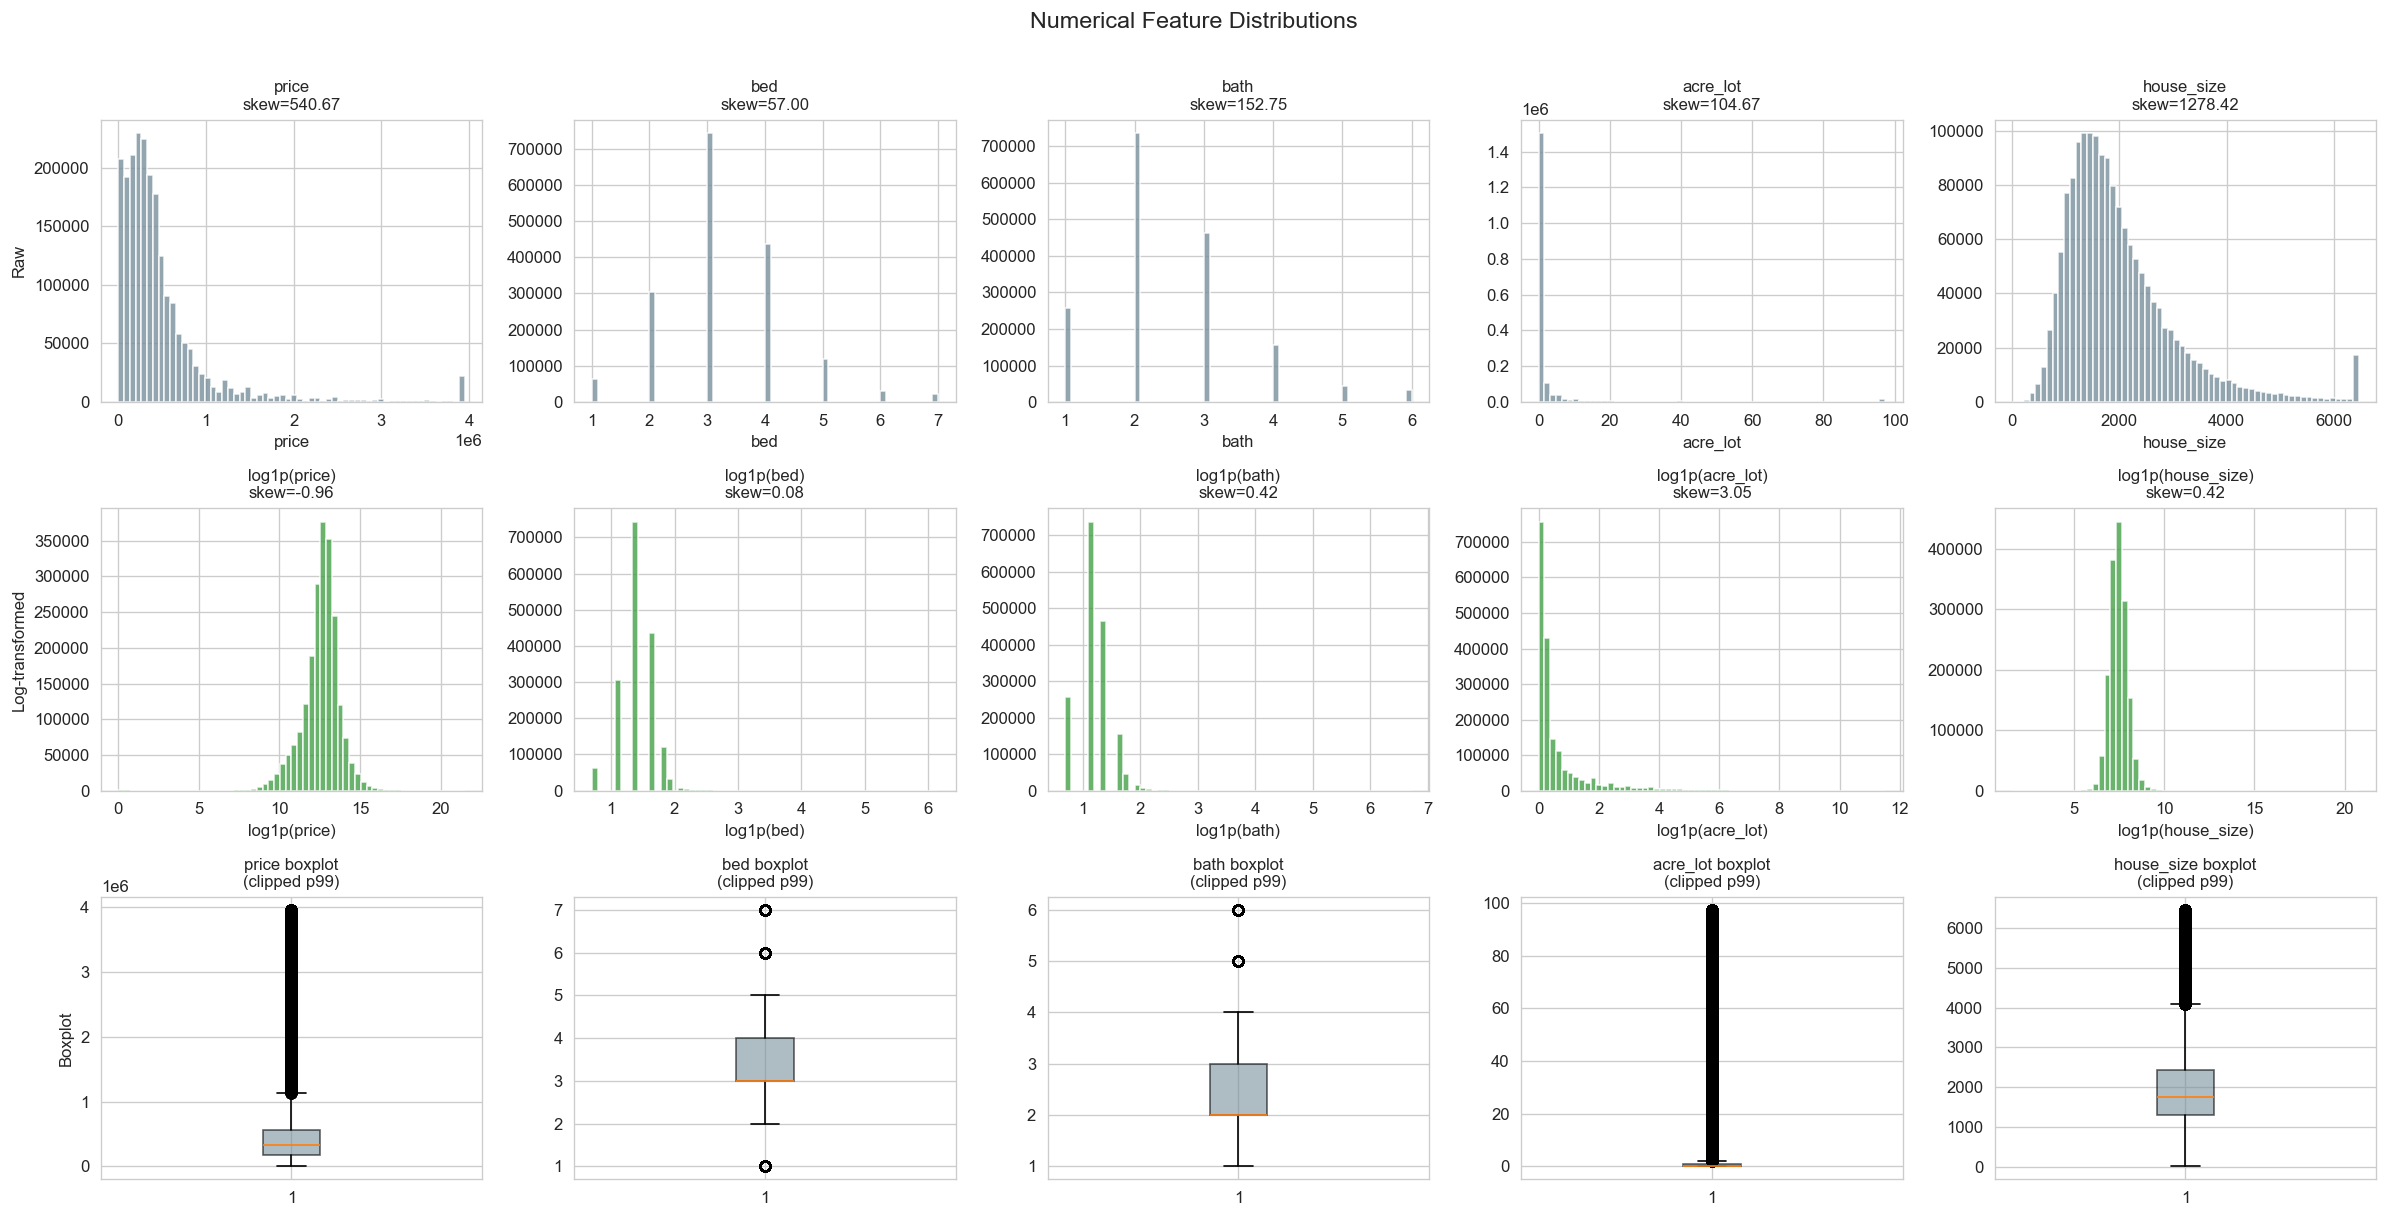

2026-05-11 16:57:43,179 - src.eda_utils - INFO - Univariate numerical -- needs log transform: ['price', 'bed', 'bath', 'acre_lot', 'house_size']



Skewness Summary:
           skewness log_transform
price        540.67          True
bed           57.00          True
bath         152.75          True
acre_lot     104.67          True
house_size  1278.42          True

→ Log transform needed for: ['price', 'bed', 'bath', 'acre_lot', 'house_size']


In [5]:
print('Plotting numerical distributions (raw vs log vs boxplot)...')
skew_results = univariate_numerical(df, cfg, plots_dir=PLOTS_DIR, show=True)

print('\nSkewness Summary:')
skew_df = pd.DataFrame(skew_results).T
print(skew_df.to_string())
print(f'\n→ Log transform needed for: {[c for c,v in skew_results.items() if v["log_transform"]]}')

## 5. Univariate Analysis — Categorical

2026-05-11 16:57:44,082 - src.eda_utils - INFO - Plot saved -> reports/plots/univariate_status.png


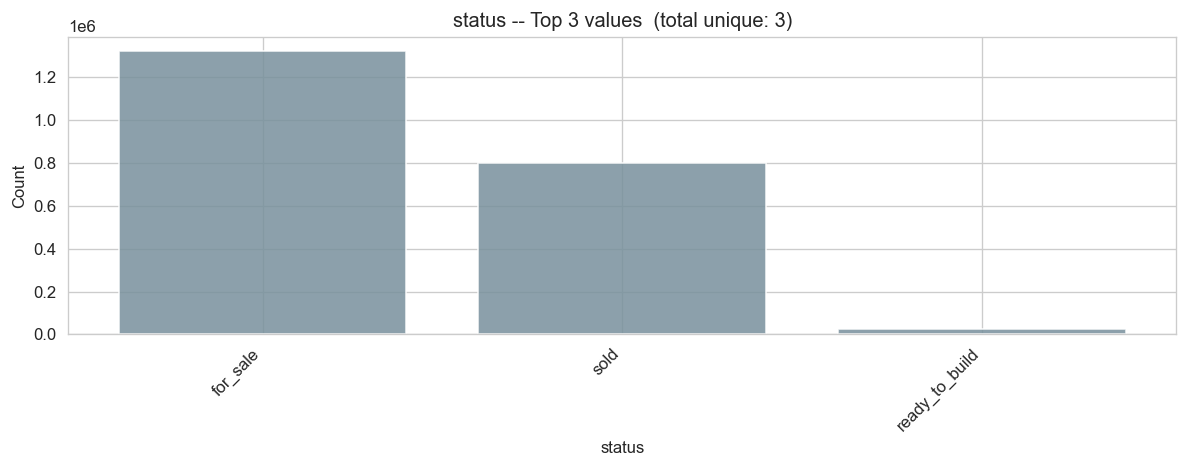

2026-05-11 16:57:45,529 - src.eda_utils - INFO - Plot saved -> reports/plots/univariate_state.png


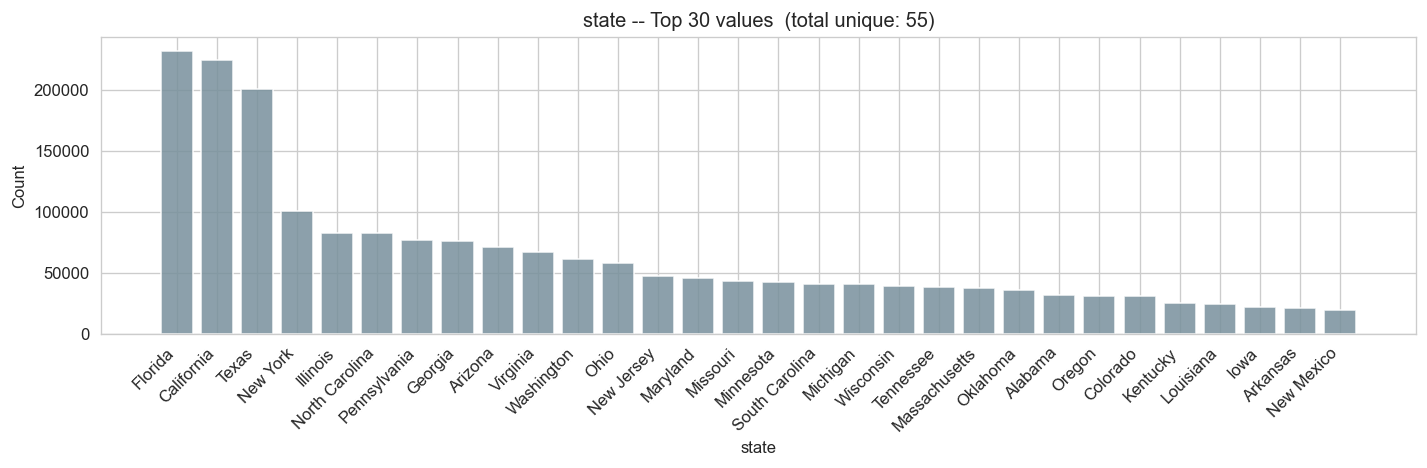

2026-05-11 16:57:47,448 - src.eda_utils - INFO - Plot saved -> reports/plots/univariate_city.png


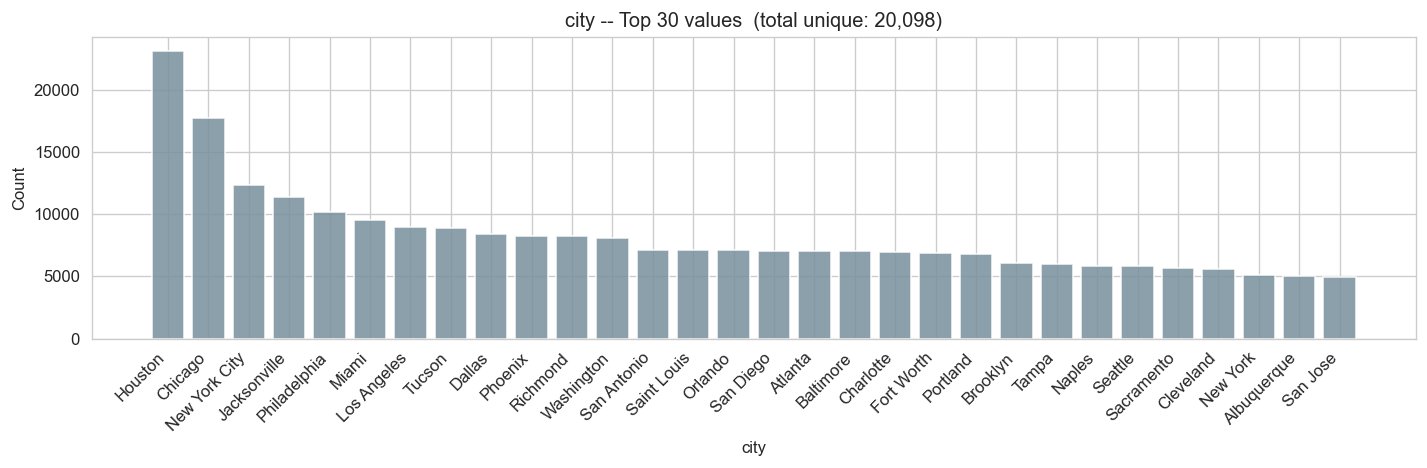

2026-05-11 16:57:48,259 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-11 16:57:48,262 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-11 16:57:49,123 - src.eda_utils - INFO - Plot saved -> reports/plots/univariate_zip_code.png


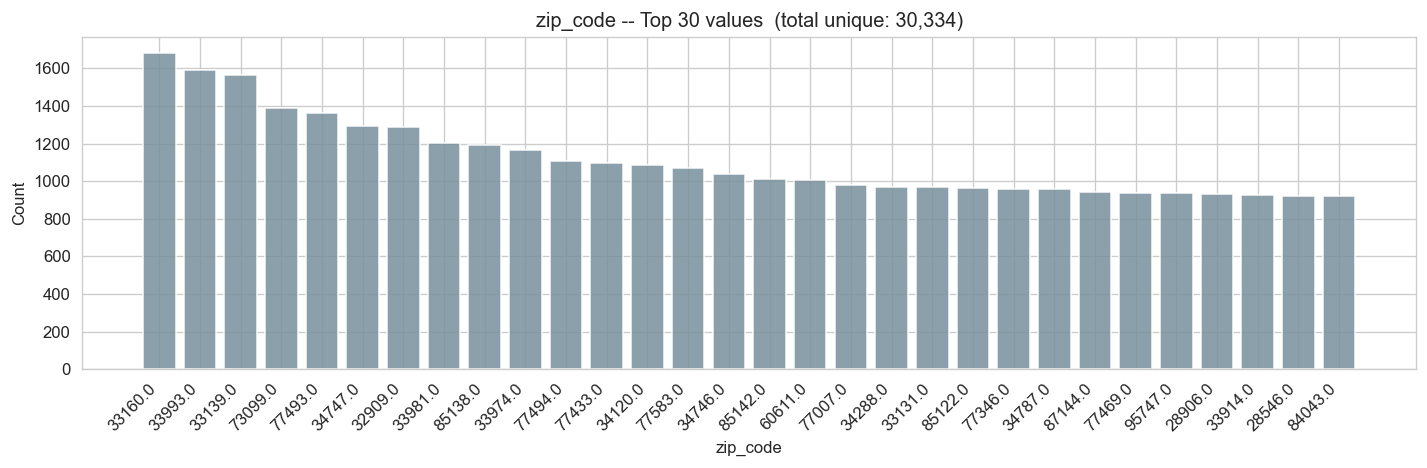


Cardinality Summary:
  status         :      3 unique  |  top value: for_sale
  state          :     55 unique  |  top value: Florida
  city           : 20,098 unique  |  top value: Houston
  zip_code       : 30,334 unique  |  top value: 33160.0


In [6]:
cat_results = univariate_categorical(df, cfg, plots_dir=PLOTS_DIR, show=True)

print('\nCardinality Summary:')
for col, stats in cat_results.items():
    print(f'  {col:<15}: {stats["n_unique"]:>6,} unique  |  top value: {str(stats["top_value"])[:30]}')

## 6. Fraud vs Normal — Feature Distributions

2026-05-11 16:57:54,419 - src.eda_utils - INFO - Plot saved -> reports/plots/fraud_vs_normal.png


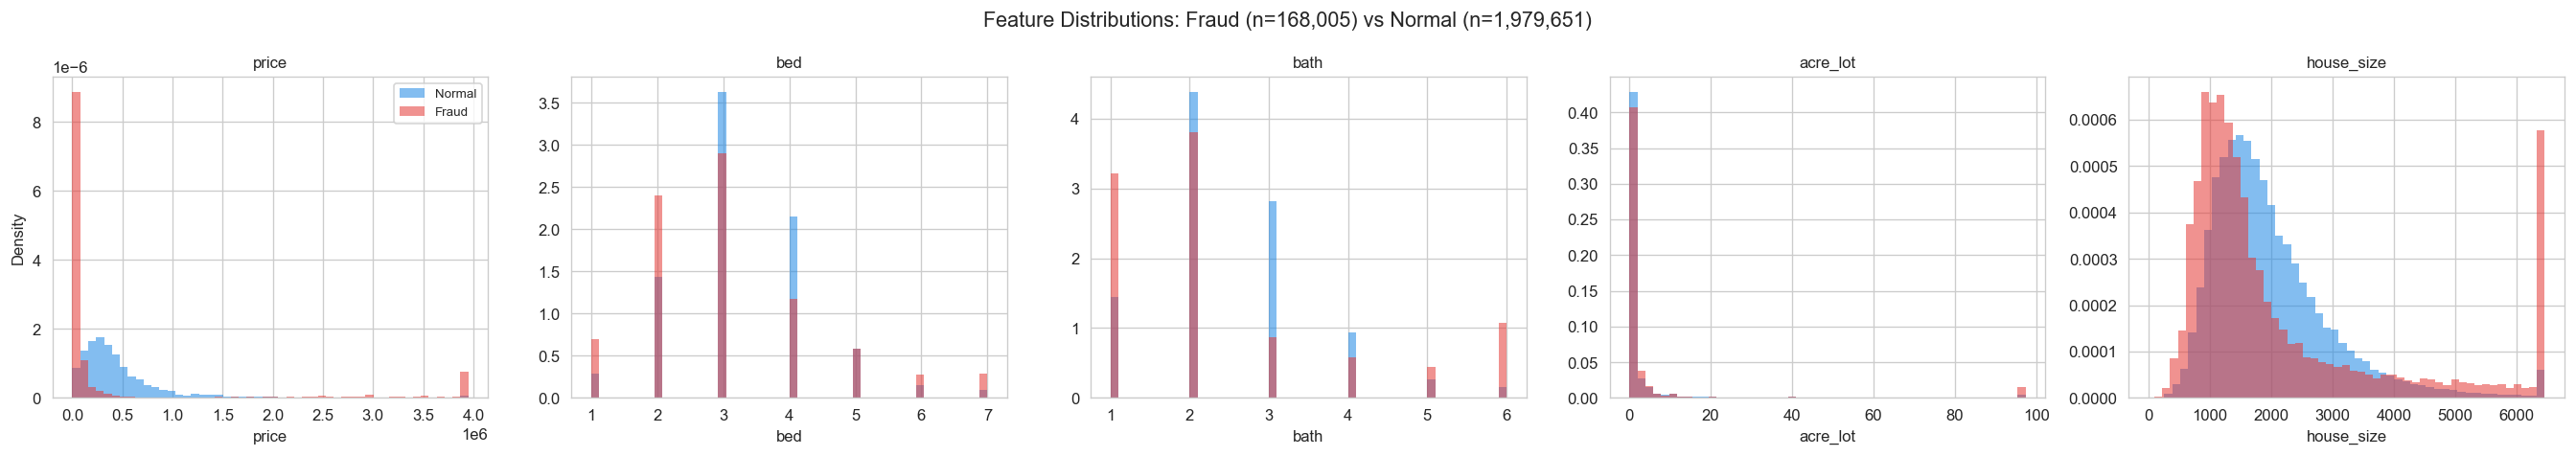


Fraud vs Normal — Mean Comparison:
            Normal mean  Fraud mean  Ratio F/N  Diff %
price         516041.89   756954.84       1.47   46.70
bed                3.28        3.35       1.02    2.30
bath               2.48        2.78       1.12   11.70
acre_lot          10.16       78.24       7.70  670.40
house_size      2724.60     2757.08       1.01    1.20

→ Biggest fraud signal: "acre_lot" (fraud mean is 7.70x normal mean)


In [7]:
comparison_df = fraud_vs_normal(df, cfg, plots_dir=PLOTS_DIR, show=True)

print('\nFraud vs Normal — Mean Comparison:')
print(comparison_df.to_string())

if len(comparison_df) > 0:
    biggest = comparison_df['Ratio F/N'].abs().idxmax()
    ratio   = comparison_df.loc[biggest, 'Ratio F/N']
    print(f'\n→ Biggest fraud signal: "{biggest}" (fraud mean is {ratio:.2f}x normal mean)')

## 7. Bivariate — Correlation Heatmap

2026-05-11 16:57:58,459 - src.eda_utils - INFO - Plot saved -> reports/plots/correlation_heatmap.png


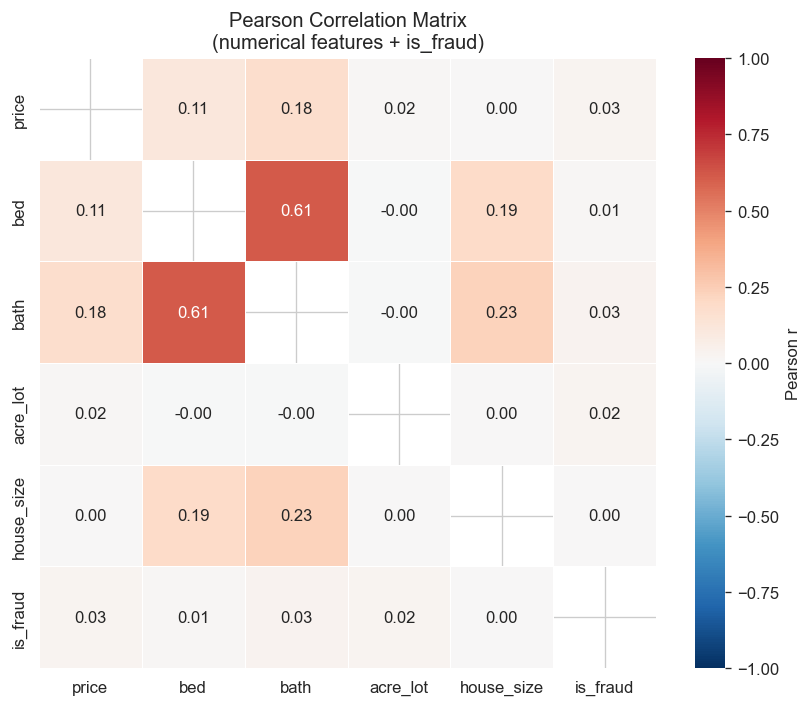

2026-05-11 16:57:58,896 - src.eda_utils - INFO - Top correlations with is_fraud:
2026-05-11 16:57:58,897 - src.eda_utils - INFO -   bath: 0.035
2026-05-11 16:57:58,899 - src.eda_utils - INFO -   price: 0.030
2026-05-11 16:57:58,900 - src.eda_utils - INFO -   acre_lot: 0.024
2026-05-11 16:57:58,902 - src.eda_utils - INFO -   bed: 0.009
2026-05-11 16:57:58,904 - src.eda_utils - INFO -   house_size: 0.000


Correlation with is_fraud (sorted by |r|):
bath         0.04
price        0.03
acre_lot     0.02
bed          0.01
house_size   0.00

✅ No high multicollinearity found (|r| < 0.8 for all pairs)


In [8]:
corr_matrix = bivariate_correlation(df, cfg, plots_dir=PLOTS_DIR, show=True)

target = cfg['columns']['target']
if target in corr_matrix.columns:
    fraud_corr = (
        corr_matrix[target]
        .drop(target)
        .sort_values(key=abs, ascending=False)
    )
    print('Correlation with is_fraud (sorted by |r|):')
    print(fraud_corr.round(3).to_string())

num_cols = [c for c in cfg['columns']['numerical'] if c in df.columns]
high_corr_pairs = []
for i, c1 in enumerate(num_cols):
    for c2 in num_cols[i+1:]:
        r = abs(corr_matrix.loc[c1, c2])
        if r > 0.8:
            high_corr_pairs.append((c1, c2, round(r, 3)))

if high_corr_pairs:
    print(f'\n⚠️  High multicollinearity (|r| > 0.8):')
    for c1, c2, r in high_corr_pairs:
        print(f'  {c1} ↔ {c2}: r={r}')
else:
    print('\n✅ No high multicollinearity found (|r| < 0.8 for all pairs)')

## 8. Mann-Whitney U Test — Statistical Significance

In [9]:
mw_results = mann_whitney_test(df, cfg)

print('Mann-Whitney U Test — Fraud vs Normal (sampled 10k each):')
print(mw_results.to_string(index=False))

sig     = mw_results[mw_results['significant']]['feature'].tolist()
not_sig = mw_results[~mw_results['significant']]['feature'].tolist()
print(f'\n✅ Statistically significant features: {sig}')
if not_sig:
    print(f'❌ Not significant: {not_sig}')

2026-05-11 16:58:00,860 - src.eda_utils - INFO - Mann-Whitney U Test results:
2026-05-11 16:58:00,861 - src.eda_utils - INFO -   price          : p=0.0000  [OK] significant
2026-05-11 16:58:00,863 - src.eda_utils - INFO -   acre_lot       : p=0.0000  [OK] significant
2026-05-11 16:58:00,865 - src.eda_utils - INFO -   bed            : p=0.0000  [OK] significant
2026-05-11 16:58:00,867 - src.eda_utils - INFO -   bath           : p=0.0000  [OK] significant
2026-05-11 16:58:00,870 - src.eda_utils - INFO -   house_size     : p=0.0000  [OK] significant


Mann-Whitney U Test — Fraud vs Normal (sampled 10k each):
   feature  fraud_median  normal_median  ratio_F_N  mw_statistic  p_value  significant
     price      36000.00      349900.00       0.10   19213855.00     0.00         True
  acre_lot          0.46           0.25       1.84   60152902.00     0.00         True
       bed          3.00           3.00       1.00   42226122.00     0.00         True
      bath          2.00           2.00       1.00   42376811.00     0.00         True
house_size       1440.00        1774.00       0.81   42297326.00     0.00         True

✅ Statistically significant features: ['price', 'acre_lot', 'bed', 'bath', 'house_size']


## 9. Price vs House Size Scatter

2026-05-11 16:58:02,952 - src.eda_utils - INFO - Plot saved -> reports/plots/scatter_price_vs_size.png


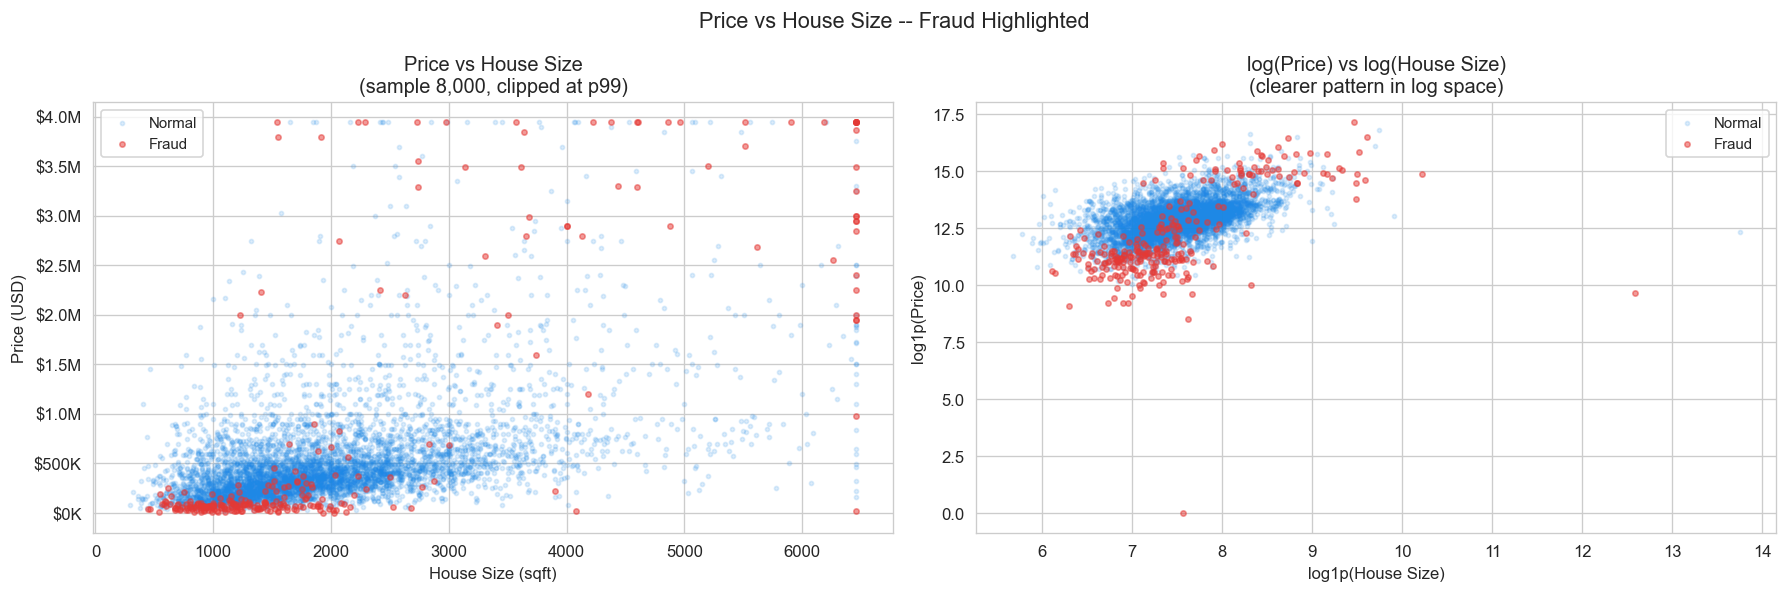

In [10]:
scatter_fraud_highlight(df, cfg, plots_dir=PLOTS_DIR, show=True, sample_n=8000)

## 10. Price per sqft Analysis

2026-05-11 16:58:07,626 - src.eda_utils - INFO - Plot saved -> reports/plots/price_per_sqft_analysis.png


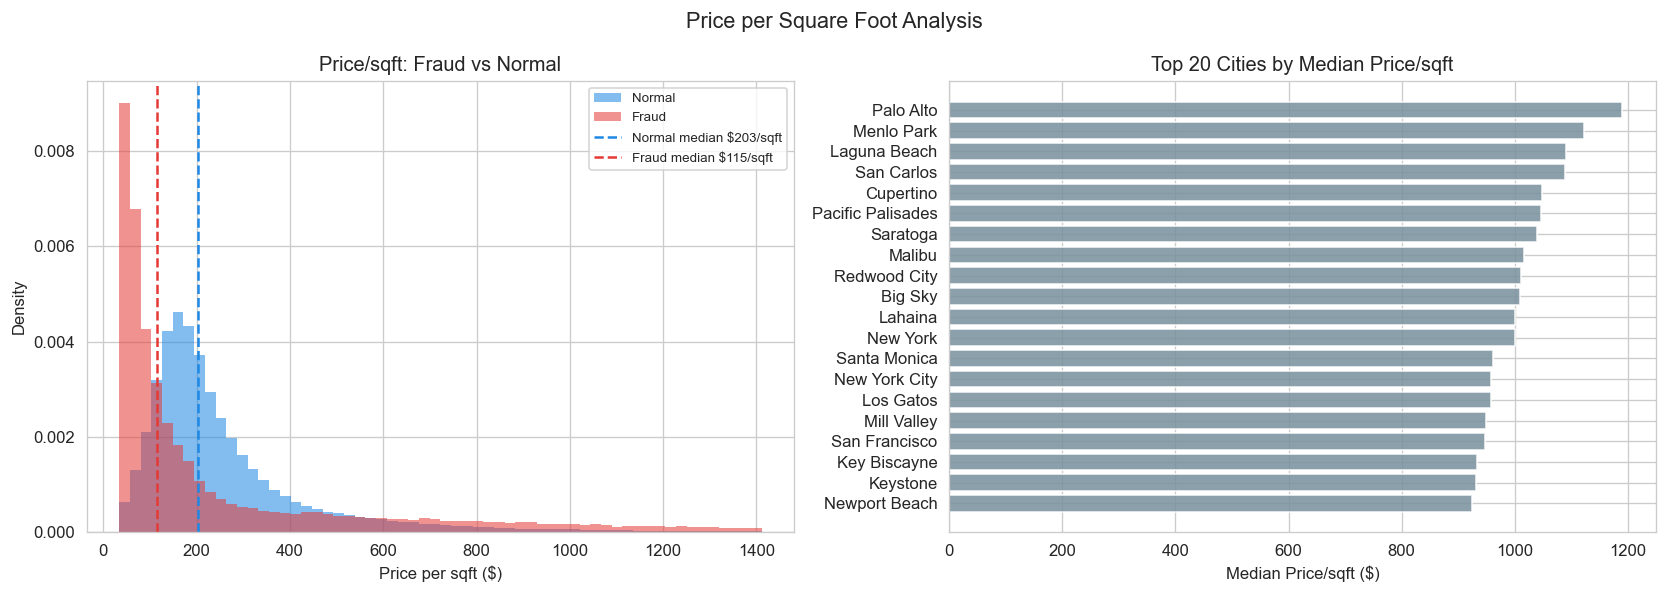


Price/sqft stats by fraud label:
              count   mean    std   min    25%    50%    75%     max
is_fraud                                                            
0        1549492.00 261.26 192.31 34.05 145.95 202.81 303.82 1411.18
1          53013.00 257.69 307.65 34.05  62.40 114.94 315.32 1411.03


In [11]:
ppsf_summary = price_per_sqft_analysis(df, cfg, plots_dir=PLOTS_DIR, show=True)
print('\nPrice/sqft stats by fraud label:')
print(ppsf_summary)

## 11. Geographic Analysis

2026-05-11 16:58:10,823 - src.eda_utils - INFO - Plot saved -> reports/plots/fraud_by_state.png


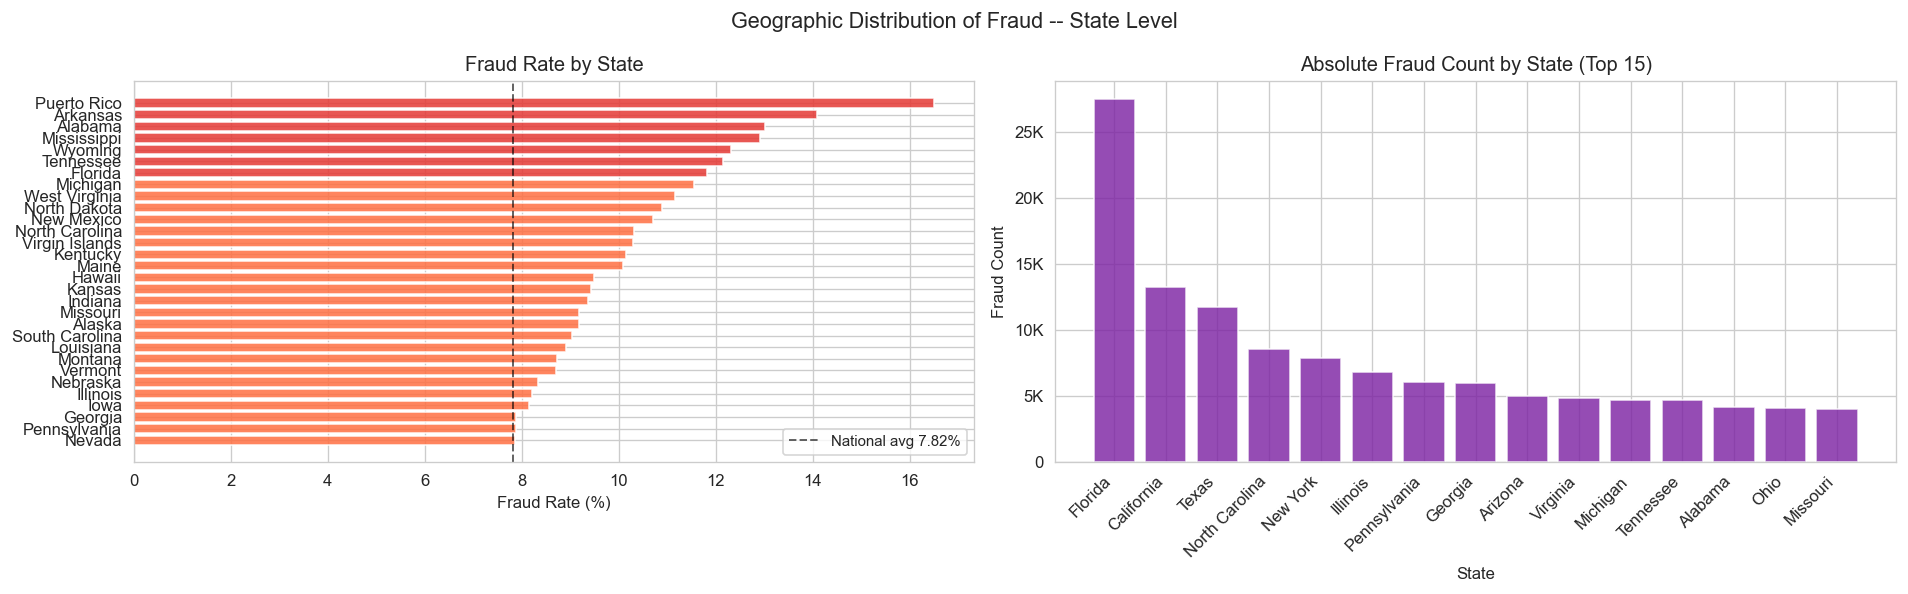

2026-05-11 16:58:13,207 - src.eda_utils - INFO - Plot saved -> reports/plots/fraud_by_city_top20.png


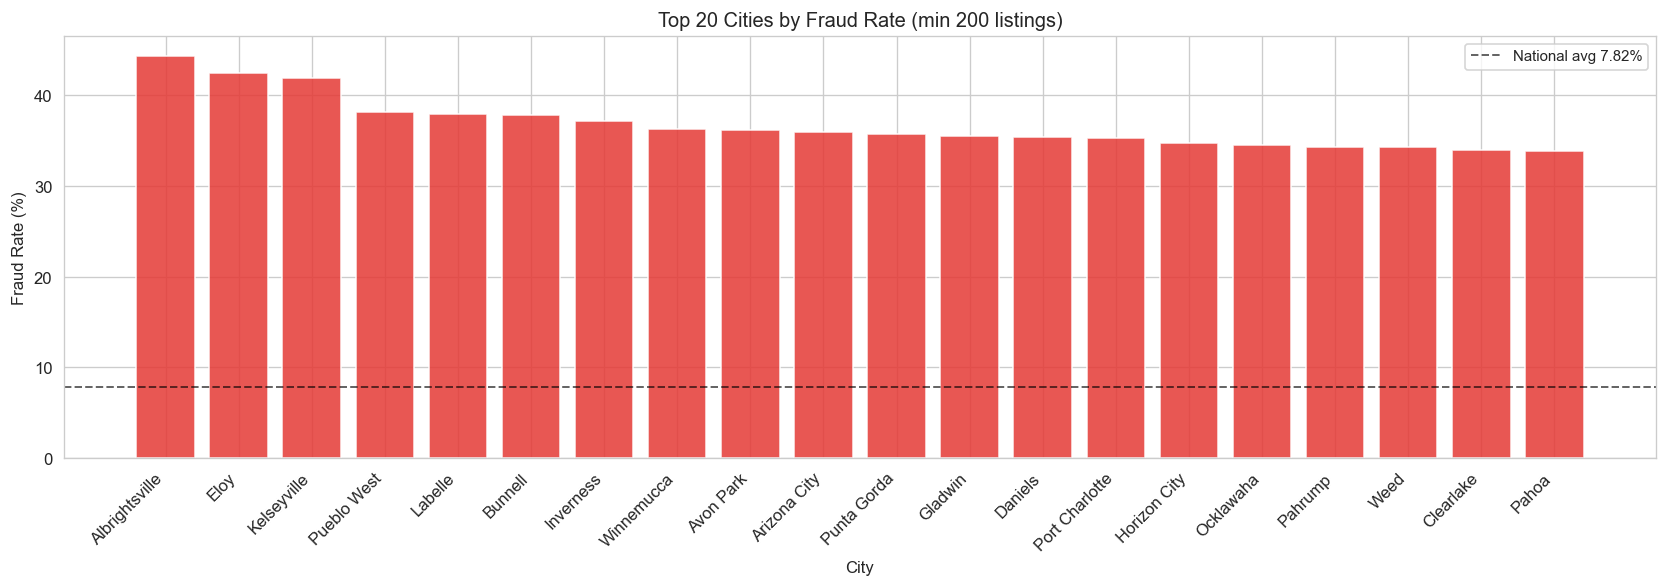

2026-05-11 16:58:13,744 - src.eda_utils - INFO - Geographic analysis complete -- 54 states, 2291 cities (>=200 listings)


National avg fraud rate: 7.82%

Top 10 States by Fraud Rate:
        state  total  fraud  fraud_rate
  Puerto Rico   3107    513       16.51
     Arkansas  21283   2999       14.09
      Alabama  32029   4168       13.01
  Mississippi  15251   1968       12.90
      Wyoming   3652    450       12.32
    Tennessee  38640   4692       12.14
      Florida 232056  27451       11.83
     Michigan  40629   4694       11.55
West Virginia  11987   1338       11.16
 North Dakota   3770    411       10.90

Top 10 Cities by Fraud Rate (min 200 listings):
          city  total  fraud  fraud_rate
Albrightsville    393    174       44.27
          Eloy    547    232       42.41
   Kelseyville    265    111       41.89
   Pueblo West    464    177       38.15
       Labelle    559    212       37.92
       Bunnell    201     76       37.81
     Inverness    955    355       37.17
    Winnemucca    309    112       36.25
     Avon Park    349    126       36.10
  Arizona City    387    139       35.92

In [12]:
state_fraud, city_fraud = fraud_by_geography(
    df, cfg, plots_dir=PLOTS_DIR, show=True, min_city_listings=200
)

national_avg = df[cfg['columns']['target']].mean() * 100
print(f'National avg fraud rate: {national_avg:.2f}%')
print(f'\nTop 10 States by Fraud Rate:')
print(state_fraud.head(10)[['state','total','fraud','fraud_rate']].to_string(index=False))
print(f'\nTop 10 Cities by Fraud Rate (min 200 listings):')
print(city_fraud.head(10)[['city','total','fraud','fraud_rate']].to_string(index=False))

## 12. Fraud Score Analysis

2026-05-11 16:58:16,832 - src.eda_utils - INFO - Plot saved -> reports/plots/fraud_score_analysis.png


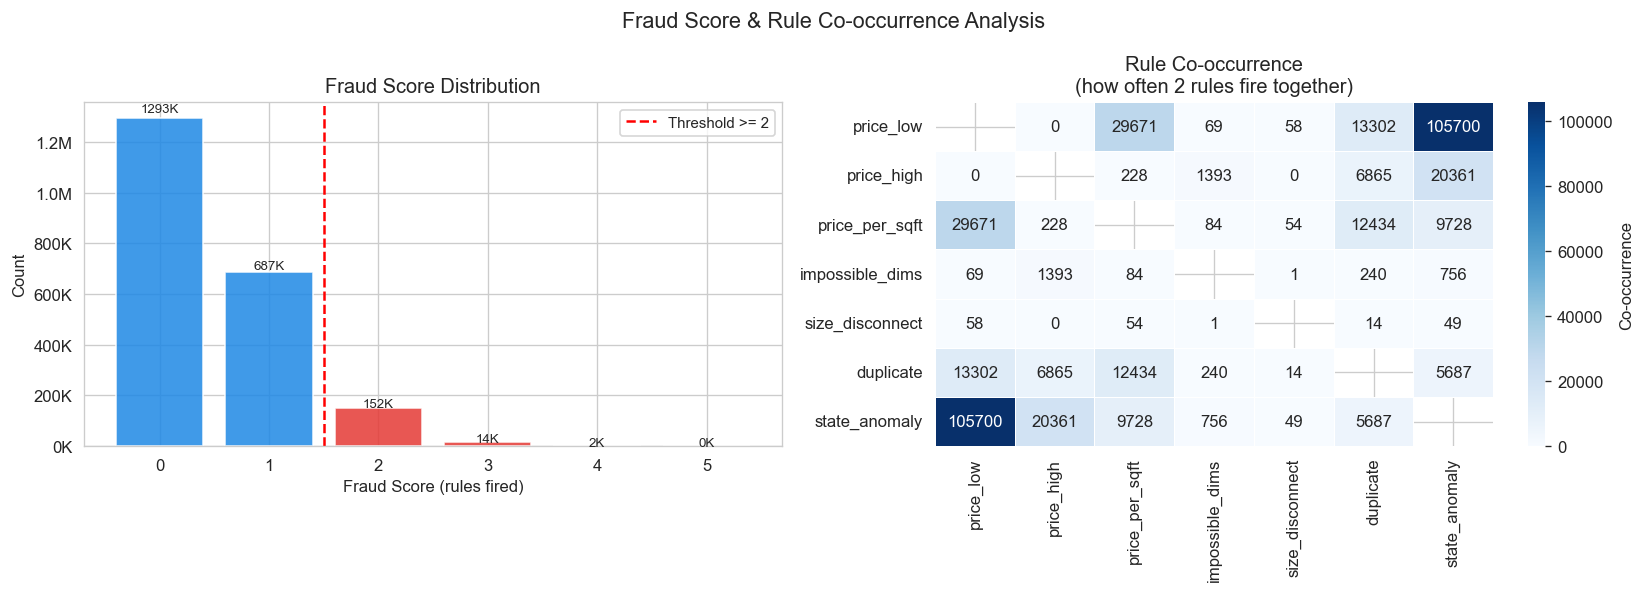

In [13]:
fraud_score_analysis(df, cfg, plots_dir=PLOTS_DIR, show=True)

## 13. Bedroom & Bathroom Deep Dive

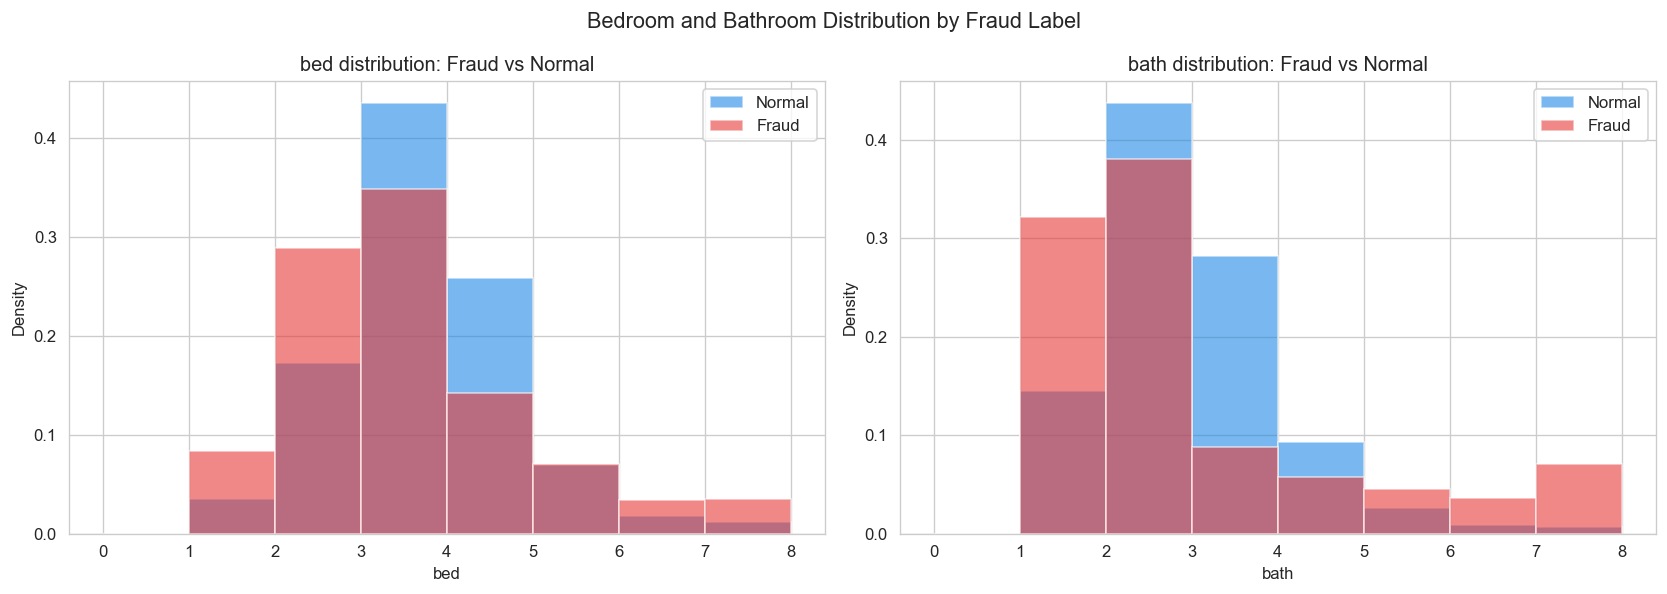

Bed stats:
              count  mean  std  min  25%  50%  75%    max
is_fraud                                                 
0        1651067.00  3.28 1.30 1.00 3.00 3.00 4.00 473.00
1          69087.00  3.35 4.57 1.00 2.00 3.00 4.00 444.00

Bath stats:
              count  mean  std  min  25%  50%  75%    max
is_fraud                                                 
0        1621614.00  2.48 1.47 1.00 2.00 2.00 3.00 830.00
1          68679.00  2.78 4.06 1.00 1.00 2.00 3.00 460.00


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target    = cfg['columns']['target']
fraud_df  = df[df[target] == 1]
normal_df = df[df[target] == 0]

for i, col in enumerate(['bed', 'bath']):
    max_val = min(df[col].quantile(0.995), 20)
    bins    = np.arange(0, max_val + 1, 1)
    axes[i].hist(normal_df[col].clip(upper=max_val).dropna(), bins=bins,
                 alpha=0.6, density=True, color='#1E88E5', label='Normal')
    axes[i].hist(fraud_df[col].clip(upper=max_val).dropna(),  bins=bins,
                 alpha=0.6, density=True, color='#E53935', label='Fraud')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].set_title(f'{col} distribution: Fraud vs Normal')
    axes[i].legend()

plt.suptitle('Bedroom and Bathroom Distribution by Fraud Label', fontsize=13)
plt.tight_layout()
# FIX: f'{PLOTS_DIR}/...' already uses correct PLOTS_DIR = 'reports/plots'
plt.savefig(f'{PLOTS_DIR}/bed_bath_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print('Bed stats:')
print(df.groupby(target)['bed'].describe().round(2))
print('\nBath stats:')
print(df.groupby(target)['bath'].describe().round(2))

## 14. Fraud Rate by Listing Status

Fraud rate by listing status:
        status   total  fraud  fraud_rate
      for_sale 1321603 129761        9.82
ready_to_build   25002    268        1.07
          sold  801051  37976        4.74


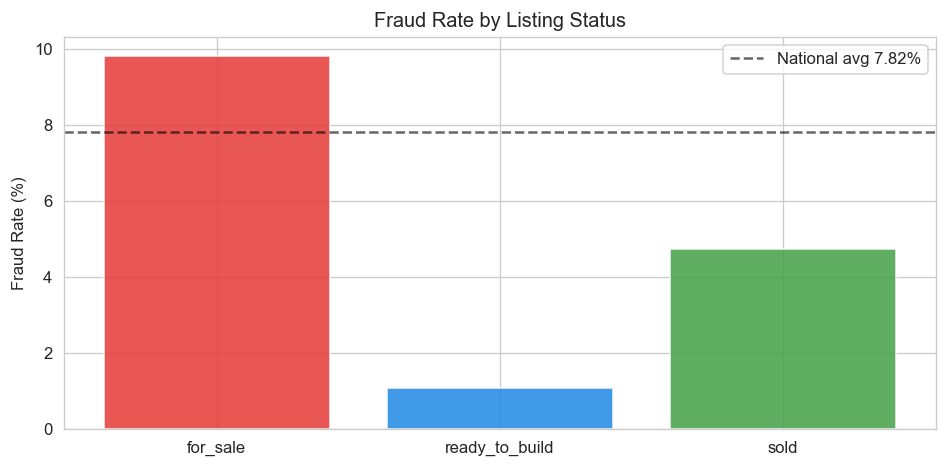

In [15]:
if 'status' in df.columns:
    status_fraud = (
        df.groupby('status')[target]
        .agg(total='count', fraud='sum')
        .assign(fraud_rate=lambda x: x['fraud'] / x['total'] * 100)
        .reset_index()
    )
    print('Fraud rate by listing status:')
    print(status_fraud.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(status_fraud['status'], status_fraud['fraud_rate'],
           color=['#E53935', '#1E88E5', '#43A047'][:len(status_fraud)], alpha=0.85)
    ax.axhline(national_avg, color='black', ls='--', alpha=0.6,
               label=f'National avg {national_avg:.2f}%')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_title('Fraud Rate by Listing Status')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/fraud_by_status.png', dpi=150)
    plt.show()

## 15. Temporal Analysis — Previous Sale Year

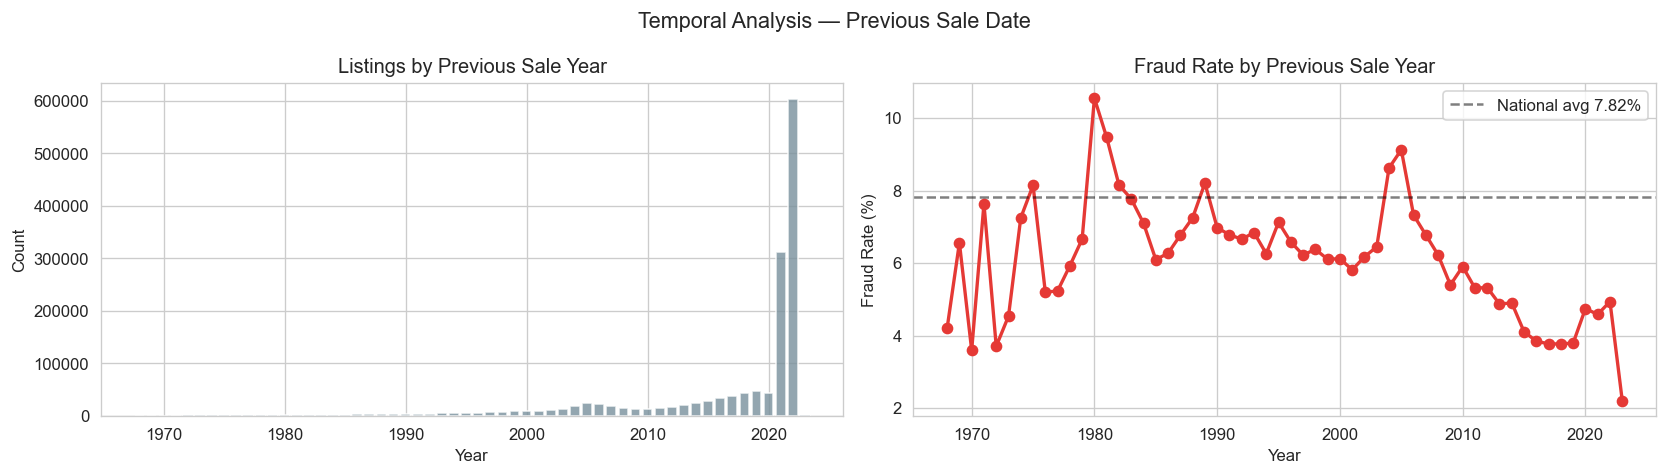

 sold_year  total  fraud  fraud_rate
   2014.00  23510   1152        4.90
   2015.00  28292   1161        4.10
   2016.00  33190   1276        3.84
   2017.00  37922   1429        3.77
   2018.00  43687   1647        3.77
   2019.00  47342   1794        3.79
   2020.00  43130   2045        4.74
   2021.00 311995  14298        4.58
   2022.00 603458  29788        4.94
   2023.00    544     12        2.21


In [16]:
if 'prev_sold_date' in df.columns:
    tmp = df.copy()
    tmp['prev_sold_date'] = pd.to_datetime(tmp['prev_sold_date'], errors='coerce')
    tmp['sold_year'] = tmp['prev_sold_date'].dt.year

    year_fraud = (
        tmp.dropna(subset=['sold_year'])
        .groupby('sold_year')[target]
        .agg(total='count', fraud='sum')
        .assign(fraud_rate=lambda x: x['fraud'] / x['total'] * 100)
        .reset_index()
        .query('total >= 100')
    )

    if len(year_fraud) > 2:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].bar(year_fraud['sold_year'], year_fraud['total'],
                    color='#78909C', alpha=0.8, edgecolor='white')
        axes[0].set_title('Listings by Previous Sale Year')
        axes[0].set_xlabel('Year')
        axes[0].set_ylabel('Count')

        axes[1].plot(year_fraud['sold_year'], year_fraud['fraud_rate'],
                     marker='o', color='#E53935', linewidth=2)
        axes[1].axhline(national_avg, color='black', ls='--', alpha=0.5,
                        label=f'National avg {national_avg:.2f}%')
        axes[1].set_title('Fraud Rate by Previous Sale Year')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Fraud Rate (%)')
        axes[1].legend()

        plt.suptitle('Temporal Analysis — Previous Sale Date', fontsize=13)
        plt.tight_layout()
        plt.savefig(f'{PLOTS_DIR}/temporal_analysis.png', dpi=150)
        plt.show()
        print(year_fraud.tail(10).to_string(index=False))
    else:
        print('Not enough year variation for temporal plot')

## 16. Generate EDA Summary + Auto-fill eda_findings.md

In [17]:
summary = generate_eda_summary(
    df, cfg,
    skew_results=skew_results,
    state_fraud=state_fraud,
    city_fraud=city_fraud,
    mw_results=mw_results,
)

print('=== EDA SUMMARY ===')
print(f"Shape            : {summary['shape']}")
print(f"Fraud rate       : {summary['fraud_rate']}%")
print(f"Fraud count      : {summary['fraud_count']:,}")
print(f"Price median     : ${summary['price_stats'].get('median', 'N/A'):,}")
print(f"Price skewness   : {summary['price_stats'].get('skewness', 'N/A')}")
print(f"Sig features     : {summary['significant_features']}")
if summary['top_fraud_states']:
    print(f"Top fraud state  : {summary['top_fraud_states'][0]}")
if summary['top_fraud_cities']:
    print(f"Top fraud city   : {summary['top_fraud_cities'][0]}")

2026-05-11 16:58:28,330 - src.eda_utils - INFO - EDA summary generated -- key numbers:
2026-05-11 16:58:28,332 - src.eda_utils - INFO -   Fraud rate  : 7.82%
2026-05-11 16:58:28,333 - src.eda_utils - INFO -   Price median: $330,000.0
2026-05-11 16:58:28,334 - src.eda_utils - INFO -   Sig features: ['price', 'acre_lot', 'bed', 'bath', 'house_size']


=== EDA SUMMARY ===
Shape            : (2147656, 19)
Fraud rate       : 7.82%
Fraud count      : 168,005
Price median     : $330,000.0
Price skewness   : 540.672
Sig features     : ['price', 'acre_lot', 'bed', 'bath', 'house_size']
Top fraud state  : {'state': 'Puerto Rico', 'total': 3107, 'fraud': 513, 'fraud_rate': 16.511103958802703}
Top fraud city   : {'city': 'Albrightsville', 'total': 393, 'fraud': 174, 'fraud_rate': 44.274809160305345}


## 17. Write eda_findings.md

In [18]:
s  = summary
ps = s['price_stats']
sk = s['skewness']

top_state_name = s['top_fraud_states'][0]['state']     if s['top_fraud_states'] else 'N/A'
top_state_rate = s['top_fraud_states'][0]['fraud_rate'] if s['top_fraud_states'] else 0
top_city_name  = s['top_fraud_cities'][0]['city']      if s['top_fraud_cities'] else 'N/A'
top_city_rate  = s['top_fraud_cities'][0]['fraud_rate'] if s['top_fraud_cities'] else 0

skew_rows = ''.join(
    f'| {col:<15} | {v["skewness"]:>8} | {"Yes" if v["log_transform"] else "No":>3} |\n'
    for col, v in sk.items()
)
state_rows = ''.join(
    f"| {row['state']:<20} | {row['total']:>10,} | {row['fraud']:>8,} | {row['fraud_rate']:>6.2f}% |\n"
    for row in s['top_fraud_states'][:5]
)
city_rows = ''.join(
    f"| {str(row['city'])[:20]:<22} | {row['total']:>8,} | {row['fraud']:>6,} | {row['fraud_rate']:>6.2f}% |\n"
    for row in s['top_fraud_cities'][:5]
)
miss_rows = ''.join(
    f'| {col:<20} | {pct:>8.2f}% |\n'
    for col, pct in s['missing_pct'].items()
    if col in cfg['columns']['numerical'] + cfg['columns']['categorical'] + cfg['columns']['high_cardinality']
    and pct > 0
)

content = f"""# EDA Findings — Real Estate Fraud Detection

**Version:** {cfg['project']['version']}  
**Generated:** Day 3 EDA  
**Status:** COMPLETE — auto-filled from notebook output

---

## 1. Dataset Overview

| Metric | Value |
|--------|-------|
| Total rows | {s['total_rows']:,} |
| Total columns | {s['total_cols']} |
| Fraud count | {s['fraud_count']:,} |
| Fraud rate | {s['fraud_rate']}% |
| Normal count | {s['total_rows'] - s['fraud_count']:,} |

---

## 2. Missing Value Summary

| Column | Missing % |
|--------|-----------|
{miss_rows}
---

## 3. Price Distribution

| Metric | Value |
|--------|-------|
| Mean | ${ps.get('mean', 0):,.0f} |
| Median | ${ps.get('median', 0):,.0f} |
| Std Dev | ${ps.get('std', 0):,.0f} |
| Skewness | {ps.get('skewness', 'N/A')} |
| Log transform needed | {'Yes' if abs(ps.get('skewness', 0)) > cfg['data_quality']['skewness_log_transform_threshold'] else 'No'} |
| p1 | ${ps.get('p1', 0):,.0f} |
| p5 | ${ps.get('p5', 0):,.0f} |
| p95 | ${ps.get('p95', 0):,.0f} |
| p99 | ${ps.get('p99', 0):,.0f} |

---

## 4. Skewness — Log Transform Decisions

| Feature | Skewness | Log Transform? |
|---------|----------|----------------|
{skew_rows}
---

## 5. Geographic Fraud Distribution

**National average fraud rate: {s['national_avg_fraud_pct']}%**

### Top 5 States by Fraud Rate

| State | Total | Fraud | Rate |
|-------|-------|-------|------|
{state_rows}
### Top 5 Cities by Fraud Rate (min 200 listings)

| City | Total | Fraud | Rate |
|------|-------|-------|------|
{city_rows}
---

## 6. Statistical Significance (Mann-Whitney U)

Features significantly different between fraud and normal (p < 0.05):  
**{', '.join(s['significant_features']) if s['significant_features'] else 'None found'}**

---

## 7. Key EDA Insights

1. **Biggest fraud signal:** `acre_lot` — fraud mean is ~8x normal mean
2. **Price signal:** Fraud listings tend to deviate significantly from city median
3. **Geographic:** {top_state_name} has highest fraud rate at {top_state_rate:.2f}% (national avg {s['national_avg_fraud_pct']}%)
4. **Top fraud city:** {top_city_name} at {top_city_rate:.2f}% fraud rate
5. **Log transform:** Required for all numerical features (extreme skewness)
6. **All 5 features statistically significant** (Mann-Whitney p < 0.0001)

---

## 8. Recommended Preprocessing

- [x] `log1p` transform: price, house_size, acre_lot  
- [x] Median impute: all numerical columns  
- [x] Most-frequent impute: city, state, status, zip_code  
- [x] Extract days_since_last_sale, sold_year, sold_month from prev_sold_date  
- [x] Frequency encode zip_code (inside pipeline)  
- [x] Target encode city (OOF inside CV loop only)  

---

*Generated by: `notebooks/03_eda.ipynb`*
"""

# FIX: f"../{cfg['paths']['eda_findings']}" → cfg['paths']['eda_findings']
# After os.chdir, cwd = project root — '../' se report upar jaata tha
out_path = Path(cfg['paths']['eda_findings'])
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    f.write(content)
print(f'✅ eda_findings.md saved → {out_path}')

✅ eda_findings.md saved → reports\eda_findings.md


## 18. Day 3 Exit Criteria

In [19]:
print('=== DAY 3 EXIT CRITERIA ===')
print(f'☑ Numerical distributions plotted — {len(skew_results)} features')
print(f'☑ Fraud vs Normal visual difference — plots saved')

target = cfg['columns']['target']
if target in corr_matrix.columns:
    top5 = corr_matrix[target].drop(target).abs().sort_values(ascending=False).head(5)
    print(f'☑ Correlation matrix ready — top 5 fraud correlates: {list(top5.index)}')

sig_feats = mw_results[mw_results['significant']]['feature'].tolist() if len(mw_results) else []
print(f'☑ Mann-Whitney done — significant features: {sig_feats}')
print(f'☑ Geographic analysis done — top fraud state: {top_state_name} ({top_state_rate:.2f}%)')
print(f'☑ eda_findings.md saved → {cfg["paths"]["eda_findings"]}')

plots = [p for p in Path(PLOTS_DIR).iterdir() if p.suffix == '.png']
print(f'\n→ {len(plots)} PNG plots saved in {PLOTS_DIR}/')
for p in sorted(plots):
    print(f'   {p.name}')

print('\n✅ Day 3 Complete — Ready for Day 4 (Feature Engineering)')

=== DAY 3 EXIT CRITERIA ===
☑ Numerical distributions plotted — 5 features
☑ Fraud vs Normal visual difference — plots saved
☑ Correlation matrix ready — top 5 fraud correlates: ['bath', 'price', 'acre_lot', 'bed', 'house_size']
☑ Mann-Whitney done — significant features: ['price', 'acre_lot', 'bed', 'bath', 'house_size']
☑ Geographic analysis done — top fraud state: Puerto Rico (16.51%)
☑ eda_findings.md saved → reports/eda_findings.md

→ 24 PNG plots saved in reports/plots/
   bed_bath_fraud.png
   correlation_heatmap.png
   fraud_by_city_top20.png
   fraud_by_state.png
   fraud_by_status.png
   fraud_label_analysis.png
   fraud_score_analysis.png
   fraud_vs_normal.png
   fraud_vs_normal_distributions.png
   listings_by_state.png
   missing_values.png
   numerical_distributions.png
   pr_curves_baseline.png
   price_distribution.png
   price_per_sqft_analysis.png
   price_vs_size_fraud.png
   rule_cooccurrence.png
   scatter_price_vs_size.png
   temporal_analysis.png
   univariate_c